In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Data from user
data = np.array([
    [6.324, 6.051408, 6.045781936],
    [6.387, 6.110754, 6.095192357],
    [6.268, 5.998656, 5.995047102],
    [6.215, 5.94873, 5.945692367],
    [6.109, 5.848878, 5.845190375],
    [6.162, 5.898804, 5.894862967]
])

# Extract columns
x = data[:, 0]
y1 = data[:, 1]
y2 = data[:, 2]

print(f"Data shape: {data.shape}")
print(f"X range: {x.min():.3f} to {x.max():.3f}")
print(f"Y1 range: {y1.min():.6f} to {y1.max():.6f}")
print(f"Y2 range: {y2.min():.6f} to {y2.max():.6f}")

Data shape: (6, 3)
X range: 6.109 to 6.387
Y1 range: 5.848878 to 6.110754
Y2 range: 5.845190 to 6.095192


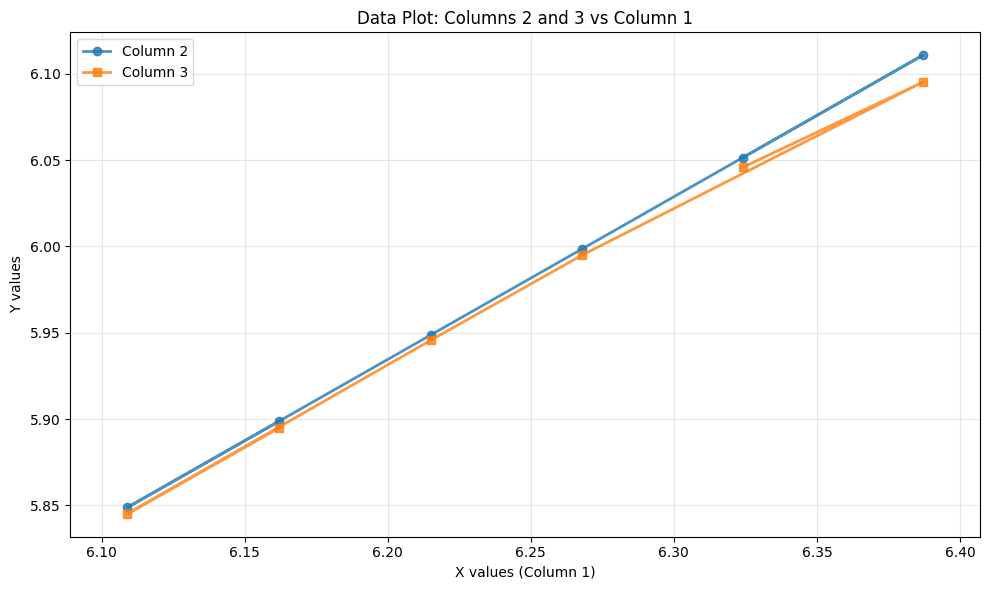

Correlation between Column 2 and Column 3: 0.999413


In [3]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot both y columns against x
ax.plot(x, y1, 'o-', label='Column 2', markersize=6, linewidth=2, color='C0', alpha=0.8)
ax.plot(x, y2, 's-', label='Column 3', markersize=6, linewidth=2, color='C1', alpha=0.8)

# Customize the plot
ax.set_xlabel('X values (Column 1)')
ax.set_ylabel('Y values')
ax.set_title('Data Plot: Columns 2 and 3 vs Column 1')
ax.grid(True, alpha=0.3)
ax.legend()

# Add some styling
ax.set_xlim(x.min() - 0.02, x.max() + 0.02)
plt.tight_layout()
plt.show()

# Print correlation between y1 and y2
correlation = np.corrcoef(y1, y2)[0, 1]
print(f"Correlation between Column 2 and Column 3: {correlation:.6f}")

In [ ]:
import xarray as xr

# Create an xarray Dataset to store the data
ds = xr.Dataset(
    {
        'column_2': (['index'], y1),
        'column_3': (['index'], y2),
    },
    coords={
        'column_1': (['index'], x),  # Use column 1 as a coordinate
        'index': range(len(x))       # Simple index coordinate
    },
    attrs={
        'description': 'User provided 3-column data',
        'created': '2025-11-04',
        'columns': 'column_1 (coord), column_2, column_3'
    }
)

print("Dataset created:")
print(ds)
print("\nDataset info:")
print(f"Dimensions: {dict(ds.dims)}")
print(f"Coordinates: {list(ds.coords.keys())}")
print(f"Data variables: {list(ds.data_vars.keys())}")

# Show a sample of the data
print("\nFirst few values:")
print(ds.head())

In [ ]:
# Save the dataset to NetCDF file
output_file = 'user_data.nc'
ds.to_netcdf(output_file)
print(f"Dataset saved to: {output_file}")

# You can also save to HDF5 format (commonly used in QCAT)
try:
    from qcat.parser.qm_reader import save_xarray_h5
    hdf5_file = 'user_data.h5'
    save_xarray_h5(ds, hdf5_file)
    print(f"Dataset also saved to HDF5: {hdf5_file}")
except ImportError:
    print("QCAT save function not available, only NetCDF saved")

# Access data from the dataset
print("\nAccessing data from dataset:")
print(f"Column 1 values: {ds.coords['column_1'].values}")
print(f"Column 2 values: {ds['column_2'].values}")
print(f"Column 3 values: {ds['column_3'].values}")

# Select data by coordinate value (example)
subset = ds.sel(column_1=6.324, method='nearest')
print(f"\nData point nearest to column_1=6.324:")
print(f"  column_2: {subset['column_2'].values:.6f}")
print(f"  column_3: {subset['column_3'].values:.6f}")